# 4. Supervised Models (Eğiticili Modeller)

Bu notebook'ta, önceki adımlarda ön işlemesi (PCA, Gauss filtresi) yapılmış ve `X_train`, `X_test`, `y_train`, `y_test` olarak kaydedilmiş yama (patch) kısımları kullanılarak temel bir Eğiticili Model (ViT) eğitimi yapılacaktır.

Lokal GPU'nuzun yetersiz olması durumunda, **bu notebook'u Google Colab'de açarak ücretsiz GPU hızlandırmasından (T4 vb.) faydalanabilirsiniz.**

### Adım 1: Google Colab ve Google Drive Hazırlığı

Google Colab üzerinde çalışıyorsanız, önceden işlenmiş olan veri setlerinizi (`.npy` dosyalarını) Google Drive'ınıza yüklemeli ve ardından Drive'ı Colab'e bağlamalısınız.

Eğer bilgisayarınızda (lokal) çalışıyorsanız, bu adım hata vermeden geçecek ve yerel yolları kullanacaktır.

In [1]:
import sys
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("\n✅ Google Colab ortamı algılandı. Drive başarıyla bağlandı.")
except ModuleNotFoundError:
    IN_COLAB = False
    print("\n💻 Lokal ortam algılandı. (VS Code vb.)")

Mounted at /content/drive

✅ Google Colab ortamı algılandı. Drive başarıyla bağlandı.


### Adım 2: Gerekli Kütüphanelerin Yüklenmesi

Model oluşturmak için PyTorch kullanılacaktır. Colab'de genelde PyTorch yüklüdür, değilse kurulacaktır.

In [2]:
if IN_COLAB:
    !pip install -q torch torchvision torchaudio scikit-learn seaborn matplotlib

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🚀 Kullanılan cihaz: {device}")


🚀 Kullanılan cihaz: cuda


### Adım 3: Verilerin Yüklenmesi

⚠️ **ÖNEMLİ:** Eğer Colab kullanıyorsanız, 3. adımdaki `datasets/processed` klasörünü (ve içindeki `indian_pines_gauss0.5_pca30_X_train.npy` vb. dosyaları) Google Drive'ınıza (Örneğin `MyDrive/hyperspectral_project/datasets/processed` şeklinde) yükleyin ve aşağıdaki `PROCESSED_DIR` değişkenini kendi Drive yolunuza göre güncelleyin.

In [3]:
if IN_COLAB:
    # TODO: Google Drive'daki işlenmiş verilerin yolunu buraya yazın
    PROCESSED_DIR = '/content/drive/MyDrive/datasets/processed'
    if not os.path.exists(PROCESSED_DIR):
        print(f"⚠️ UYARI: {PROCESSED_DIR} bulunamadı! Lütfen verilerinizi Drive'a yükleyin ve yolu güncelleyin.")
else:
    # Lokal kullanımda direkt proje içerisindeki yolu kullanıyoruz
    PROCESSED_DIR = './datasets/processed'

# Hangi veri setini eğiteceğimizi seçiyoruz
dataset_prefix = 'indian_pines_gauss0.5_pca30'

try:
    X_train = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_X_train.npy'))
    y_train = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_y_train.npy'))
    X_test  = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_X_test.npy'))
    y_test  = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_y_test.npy'))
    
    print("✅ Veriler başarıyla yüklendi:")
    print(f"X_train boyutu: {X_train.shape}")
    print(f"y_train boyutu: {y_train.shape}")
    print(f"X_test boyutu: {X_test.shape}")
    print(f"y_test boyutu: {y_test.shape}")
except FileNotFoundError:
    print("❌ Veri dosyaları bulunamadı! Lütfen dosya yollarını kontrol edin.")

✅ Veriler başarıyla yüklendi:
X_train boyutu: (1024, 15, 15, 30)
y_train boyutu: (1024,)
X_test boyutu: (9225, 15, 15, 30)
y_test boyutu: (9225,)


### Adım 4: PyTorch DataLoader Hazırlığı ve Model Tanımlaması

PyTorch'ta ViT modelleri görüntülerin **(Batch, Channel, Height, Width)** formatında olmasını bekler. Verimiz şu anda `(N, H, W, C)` formatındaysa, eksenleri kaydırmamız gerekir.

In [4]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from IPython.display import display

class HSI_ViT(nn.Module):
    def __init__(self, num_classes, image_size=15, patch_size=3, input_channels=30, embed_dim=128, depth=4, heads=8, mlp_dim=256, dropout=0.1):
        super(HSI_ViT, self).__init__()
        assert image_size % patch_size == 0, 'Image dimensions must be divisible by the patch size.'
        num_patches = (image_size // patch_size) ** 2
        patch_dim = input_channels * patch_size ** 2

        self.patch_size = patch_size
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.patch_to_embedding = nn.Linear(patch_dim, embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=mlp_dim, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, img):
        B, C, H, W = img.shape
        p = self.patch_size
        x = img.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(B, C, -1, p, p)
        x = x.permute(0, 2, 1, 3, 4).contiguous().view(B, -1, C * p * p)
        
        x = self.patch_to_embedding(x)
        b, n, _ = x.shape

        cls_tokens = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.transformer(x)

        x = x[:, 0]
        return self.mlp_head(x)

# Tüm veriyi birleştirip K-Fold için hazırlayalım
X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

if len(X_all.shape) == 4 and X_all.shape[-1] == 30:
    X_all_t = np.transpose(X_all, (0, 3, 1, 2))
else:
    X_all_t = X_all

# PyTorch'taki CrossEntropyLoss etiketlerin 0'dan başlamasını bekler.
y_all_zero_indexed = y_all - 1
num_classes = len(np.unique(y_all))

batch_size = 64
num_epochs = 30
k_folds = 10
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_results = []

print(f"{k_folds}-Fold Cross Validation Başlıyor...")


10-Fold Cross Validation Başlıyor...


### Adım 5: Model Eğitimi (K-Fold Cross Validation)

Hazırlanan DataLoader'lar ile modeli eğitiyoruz.

In [5]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
oof_preds = []
oof_labels = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all_t, y_all_zero_indexed)):
    print(f"\n=== Fold {fold+1} ===")
    
    X_train_fold = torch.tensor(X_all_t[train_idx], dtype=torch.float32)
    y_train_fold = torch.tensor(y_all_zero_indexed[train_idx], dtype=torch.long)
    X_test_fold = torch.tensor(X_all_t[test_idx], dtype=torch.float32)
    y_test_fold = torch.tensor(y_all_zero_indexed[test_idx], dtype=torch.long)
    
    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    test_dataset = TensorDataset(X_test_fold, y_test_fold)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    model = HSI_ViT(num_classes=num_classes, input_channels=30).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    fold_train_loss, fold_train_acc = [], []
    fold_val_loss, fold_val_acc = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()
            total += inputs.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        fold_train_loss.append(epoch_train_loss)
        fold_train_acc.append(epoch_train_acc)
        
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels).item()
                val_total += inputs.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        fold_val_loss.append(epoch_val_loss)
        fold_val_acc.append(epoch_val_acc)
        
    history['train_loss'].append(fold_train_loss)
    history['train_acc'].append(fold_train_acc)
    history['val_loss'].append(fold_val_loss)
    history['val_acc'].append(fold_val_acc)
    
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    all_preds = np.array(all_preds) + 1
    all_labels = np.array(all_labels) + 1
    
    oof_preds.extend(all_preds)
    oof_labels.extend(all_labels)
    
    acc = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    kappa = cohen_kappa_score(all_labels, all_preds) * 100
    
    fold_results.append({
        'Fold': f'Fold {fold+1}',
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Kappa': kappa
    })
    
    print(f"Fold {fold+1} Tamamlandı - Acc: %{acc:.2f}")




=== Fold 1 ===
Fold 1 Tamamlandı - Acc: %99.71

=== Fold 2 ===
Fold 2 Tamamlandı - Acc: %100.00

=== Fold 3 ===
Fold 3 Tamamlandı - Acc: %99.32

=== Fold 4 ===
Fold 4 Tamamlandı - Acc: %99.90

=== Fold 5 ===
Fold 5 Tamamlandı - Acc: %99.71

=== Fold 6 ===
Fold 6 Tamamlandı - Acc: %99.51

=== Fold 7 ===
Fold 7 Tamamlandı - Acc: %99.32

=== Fold 8 ===
Fold 8 Tamamlandı - Acc: %99.80

=== Fold 9 ===
Fold 9 Tamamlandı - Acc: %99.61

=== Fold 10 ===
Fold 10 Tamamlandı - Acc: %99.22


### Adım 6: Eğitim Sonuçlarının Gösterilmesi

K-Fold sonuçlarını tablo halinde gösteriyoruz.

In [6]:
df_results = pd.DataFrame(fold_results)
df_results.set_index('Fold', inplace=True)

mean_row = df_results.mean()
std_row = df_results.std()

avg_std_row = {
    col: f"{mean_row[col]:.2f} ± {std_row[col]:.2f}"
    for col in df_results.columns
}

for col in df_results.columns:
    df_results[col] = df_results[col].apply(lambda x: f"{x:.2f}")

df_results.loc['Avg ± Std'] = avg_std_row

print("\n--- 10-Fold Cross Validation Sonuçları ---")
display(df_results)



--- 10-Fold Cross Validation Sonuçları ---


,Accuracy,Precision,Recall,F1-Score,Kappa
Fold,,,,,
Fold 1,99.71,98.82,98.54,98.55,99.67
Fold 2,100.00,100.00,100.00,100.00,100.00
Fold 3,99.32,99.78,99.47,99.61,99.22
Fold 4,99.90,99.94,99.97,99.96,99.89
Fold 5,99.71,99.85,99.89,99.87,99.67
Fold 6,99.51,99.73,99.80,99.77,99.44
Fold 7,99.32,98.70,99.53,99.05,99.22
Fold 8,99.80,99.82,99.05,99.41,99.78
Fold 9,99.61,99.81,99.49,99.64,99.56


### Adım 7: Model Sonuçlarının Görselleştirilmesi

Eklenen görselleştirmeler şunlardır:
1. **Eğitim ve Doğrulama Loss/Accuracy Eğrileri**
2. **Karışıklık Matrisi (Confusion Matrix)**
3. **Sınıf Bazlı F1-Skoru Dağılımı**

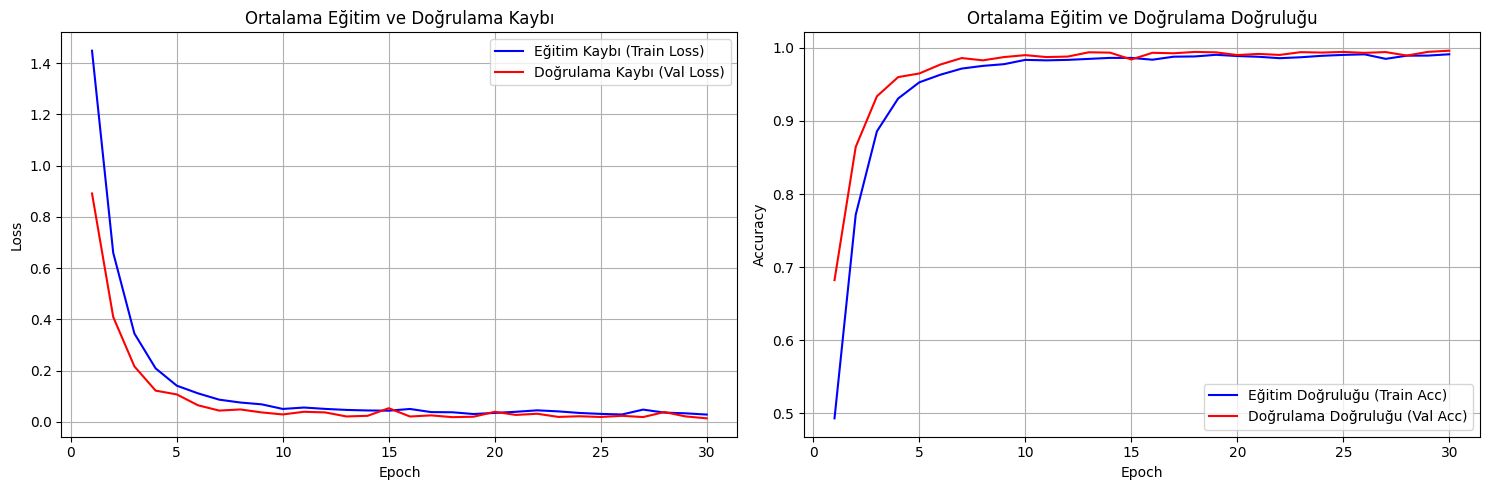

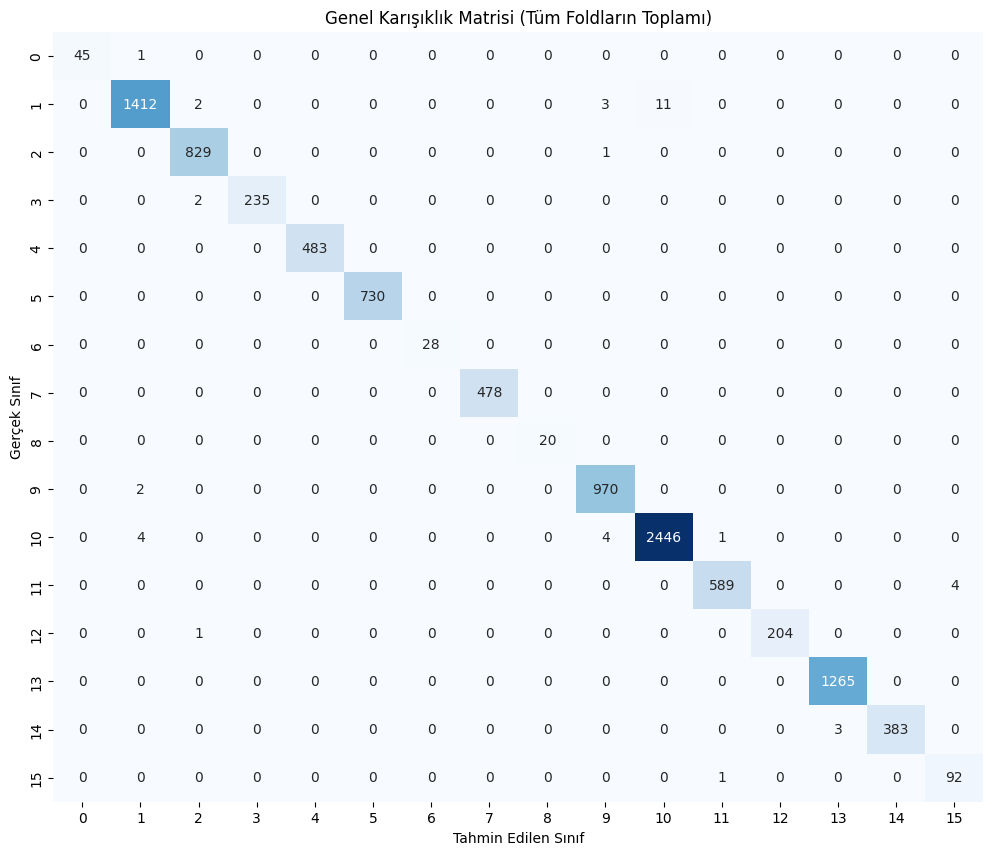

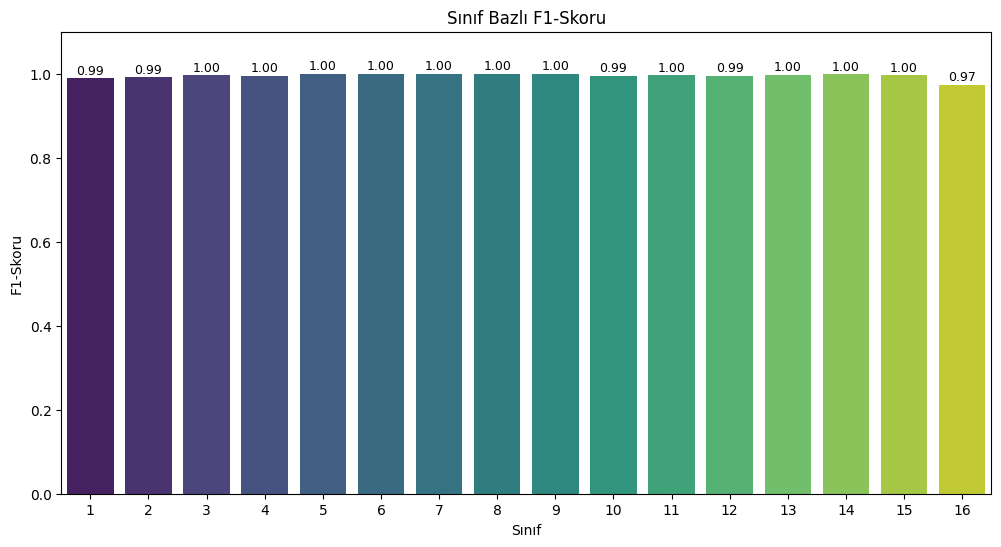

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Ortalama eğitim ve doğrulama kayıpları/doğrulukları hesaplanıyor
mean_train_loss = np.mean(history['train_loss'], axis=0)
mean_val_loss = np.mean(history['val_loss'], axis=0)
mean_train_acc = np.mean(history['train_acc'], axis=0)
mean_val_acc = np.mean(history['val_acc'], axis=0)
epochs = range(1, len(mean_train_loss) + 1)

axes[0].plot(epochs, mean_train_loss, 'b-', label='Eğitim Kaybı (Train Loss)')
axes[0].plot(epochs, mean_val_loss, 'r-', label='Doğrulama Kaybı (Val Loss)')
axes[0].set_title('Ortalama Eğitim ve Doğrulama Kaybı')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, mean_train_acc, 'b-', label='Eğitim Doğruluğu (Train Acc)')
axes[1].plot(epochs, mean_val_acc, 'r-', label='Doğrulama Doğruluğu (Val Acc)')
axes[1].set_title('Ortalama Eğitim ve Doğrulama Doğruluğu')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ----------------- Karışıklık Matrisi -----------------
plt.figure(figsize=(12, 10))
cm = confusion_matrix(oof_labels, oof_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Genel Karışıklık Matrisi (Tüm Foldların Toplamı)')
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.show()

# ----------------- Sınıf Bazlı Performans Raporu -----------------
report = classification_report(oof_labels, oof_preds, output_dict=True)
classes = [k for k in report.keys() if k.isdigit()]
f1_scores = [report[k]['f1-score'] for k in classes]

plt.figure(figsize=(12, 6))
sns.barplot(x=classes, y=f1_scores, hue=classes, palette='viridis', dodge=False, legend=False)
plt.title('Sınıf Bazlı F1-Skoru')
plt.xlabel('Sınıf')
plt.ylabel('F1-Skoru')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.show()


In [8]:
import shutil
import os
model_save_path = f"vit_model_{dataset_prefix}.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model başarıyla '{model_save_path}' konumuna kaydedildi.")


if IN_COLAB:
    # Modeli Google Drive'a kopyalayalım
    drive_save_path = os.path.join('/content/drive/MyDrive/models', f'vit_model_{dataset_prefix}.pth')
    os.makedirs(os.path.dirname(drive_save_path), exist_ok=True)
    shutil.copy(model_save_path, drive_save_path)
    print(f"Model Google Drive'a '{drive_save_path}' konumuna kopyalandı.")


Model başarıyla 'vit_model_indian_pines_gauss0.5_pca30.pth' konumuna kaydedildi.
Model Google Drive'a '/content/drive/MyDrive/models/vit_model_indian_pines_gauss0.5_pca30.pth' konumuna kopyalandı.
